In [1]:
!pip install -U langchain
!pip install -U langgraph
!pip install -U langchain-google-genai
!pip install -U langchain-community
!pip install -U langchain-chroma
!pip install -U langchain-huggingface
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 14.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4.8:
      Successfully uninstalled langchain-core-1.4.8
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.11
    Uninstalling langchain-1.3.11:
      Successfully uninstalled langchain-1.3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.6
    Uninstalling langgraph-1.2.6:
      Successfully uninstalled langgraph-1.2.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

In [6]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
#from langchain_openai import ChatOpenAI
#from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
#from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

/tmp/ipykernel_2562/697897779.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [7]:
from google.colab import userdata
import os

gemini_api_key = userdata.get("GOOGLE_API_KEY")

if not gemini_api_key:
    raise ValueError("GOOGLE_API_KEY not found.")

os.environ["GOOGLE_API_KEY"] = gemini_api_key

In [14]:
!pip install -U faiss-cpu

In [15]:
from langchain_community.vectorstores import FAISS

In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

In [16]:
from typing import TypedDict, Dict, List

#from langchain_openai import ChatOpenAI, OpenAIEmbeddings
#from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END


# -------------------------------------------------------------------
# LLM & EMBEDDINGS
# -------------------------------------------------------------------



llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


# -------------------------------------------------------------------
# VECTOR DATABASE (FRAUD / AML KNOWLEDGE)
# -------------------------------------------------------------------

documents = [
    Document(page_content="Rapid high-value transactions may indicate account takeover."),
    Document(page_content="Transactions inconsistent with historical behavior are strong fraud indicators."),
    Document(page_content="Cross-border transfers above thresholds require enhanced AML checks."),
    Document(page_content="Multiple failed logins followed by a large transfer indicate fraud."),
    Document(page_content="Dormant accounts suddenly becoming active is a known laundering pattern.")
]

vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [17]:
# -------------------------------------------------------------------
# UPDATED SHARED STATE
# -------------------------------------------------------------------

class FraudState(TypedDict):
    transaction: Dict[str, float]
    user_profile: Dict[str, float]
    remaining_agents: List[str]

    behavior_assessment: str
    pattern_assessment: str
    compliance_assessment: str

    final_risk: str
    action: str


# -------------------------------------------------------------------
# ORCHESTRATOR (SEQUENTIAL PLANNER)
# -------------------------------------------------------------------

import json

def orchestrator_agent(state: FraudState):

    prompt = f"""
    You are a fraud investigation planner.

    Transaction:
    {state["transaction"]}

    User profile:
    {state["user_profile"]}

    Decide execution order using:
    - behavior
    - pattern
    - compliance

    Respond ONLY in JSON:

    {{
        "execution_order": ["behavior", "pattern", "compliance"]
    }}
    """

    response = llm.invoke(prompt).content.strip()

    try:
        parsed = json.loads(response)
        state["remaining_agents"] = parsed["execution_order"]
    except:
        state["remaining_agents"] = ["behavior", "pattern", "compliance"]

    return state




def first_router(state: FraudState):
    return state["remaining_agents"][0]



In [18]:
def behavior_agent(state: FraudState):
    state["behavior_assessment"] = llm.invoke(
        f"Assess behavior risk: {state['user_profile']}"
    ).content

    state["remaining_agents"].pop(0)
    return state


def pattern_agent(state: FraudState):
    retrieved = retriever.invoke("transaction anomaly")
    context = "\n".join(d.page_content for d in retrieved)

    state["pattern_assessment"] = llm.invoke(
        f"Assess pattern risk using context:\n{context}"
    ).content

    state["remaining_agents"].pop(0)
    return state


def compliance_agent(state: FraudState):
    state["compliance_assessment"] = llm.invoke(
        f"Assess AML risk: {state['transaction']}"
    ).content

    state["remaining_agents"].pop(0)
    return state


In [19]:
def judge_agent(state: FraudState):
    prompt = f"""
    You are a senior fraud risk judge.

    Behavior assessment:
    {state.get("behavior_assessment", "")}

    Pattern assessment:
    {state.get("pattern_assessment", "")}

    Compliance assessment:
    {state.get("compliance_assessment", "")}

    Decide overall fraud risk.

    Respond with exactly one word:
    LOW, MEDIUM, or HIGH
    """

    state["final_risk"] = llm.invoke(prompt).content.strip()
    return state


In [20]:
def action_agent(state: FraudState):

    risk = state.get("final_risk", "LOW")

    if "HIGH" in risk:
        state["action"] = "BLOCK_TRANSACTION"
    elif "MEDIUM" in risk:
        state["action"] = "ESCALATE_TO_HUMAN"
    else:
        state["action"] = "ALLOW_TRANSACTION"

    return state


In [21]:
def report_node(state: FraudState):

    print("\n========== FRAUD INVESTIGATION REPORT ==========")
    print("Transaction:", state["transaction"])
    print("User Profile:", state["user_profile"])
    print("\nBehavior Assessment:\n", state.get("behavior_assessment", "N/A"))
    print("\nPattern Assessment:\n", state.get("pattern_assessment", "N/A"))
    print("\nCompliance Assessment:\n", state.get("compliance_assessment", "N/A"))
    print("\nFINAL RISK:", state.get("final_risk", "UNKNOWN"))
    print("ACTION:", state.get("action", "NONE"))
    print("===============================================\n")

    return state


In [22]:
graph = StateGraph(FraudState)

graph.add_node("orchestrator", orchestrator_agent)
graph.add_node("behavior", behavior_agent)
graph.add_node("pattern", pattern_agent)
graph.add_node("compliance", compliance_agent)
graph.add_node("judge", judge_agent)
graph.add_node("action", action_agent)
graph.add_node("report", report_node)

graph.set_entry_point("orchestrator")

graph.add_conditional_edges(
    "orchestrator",
    first_router,
    {
        "behavior": "behavior",
        "pattern": "pattern",
        "compliance": "compliance"
    }
)

# Fixed sequential flow
graph.add_edge("behavior", "pattern")
graph.add_edge("pattern", "compliance")
graph.add_edge("compliance", "judge")
graph.add_edge("judge", "action")
graph.add_edge("action", "report")
graph.add_edge("report", END)

app = graph.compile()


In [23]:
app.invoke({
    "transaction": {
        "amount": 15000,
        "country_risk_score": 0.9,
        "hour": 2
    },
    "user_profile": {
        "account_age_years": 0.4,
        "avg_transaction": 300,
        "login_failures": 5
    },
    "remaining_agents": [],
    "behavior_assessment": "",
    "pattern_assessment": "",
    "compliance_assessment": "",
    "final_risk": "",
    "action": ""
})



========== FRAUD INVESTIGATION REPORT ==========
Transaction: {'amount': 15000, 'country_risk_score': 0.9, 'hour': 2}
User Profile: {'account_age_years': 0.4, 'avg_transaction': 300, 'login_failures': 5}

Behavior Assessment:
 This behavior profile indicates a **high risk** of fraudulent activity or account compromise.

Here's a breakdown of why:

1.  **Account Age (0.4 years):** A very new account (less than 5 months old) lacks established history, making it inherently higher risk. New accounts are often used for testing stolen credentials, for short-term fraudulent schemes, or by individuals who might quickly abandon them after a single transaction.

2.  **Login Failures (5):** This is a significant number of failed login attempts. While a legitimate user might forget their password once or twice, five failures strongly suggest either a brute-force attack, credential stuffing, or an unauthorized user attempting to gain access.

3.  **Average Transaction ($300):** This is a moderate 

{'transaction': {'amount': 15000, 'country_risk_score': 0.9, 'hour': 2},
 'user_profile': {'account_age_years': 0.4,
  'avg_transaction': 300,
  'login_failures': 5},
 'remaining_agents': [],
 'behavior_assessment': "This behavior profile indicates a **high risk** of fraudulent activity or account compromise.\n\nHere's a breakdown of why:\n\n1.  **Account Age (0.4 years):** A very new account (less than 5 months old) lacks established history, making it inherently higher risk. New accounts are often used for testing stolen credentials, for short-term fraudulent schemes, or by individuals who might quickly abandon them after a single transaction.\n\n2.  **Login Failures (5):** This is a significant number of failed login attempts. While a legitimate user might forget their password once or twice, five failures strongly suggest either a brute-force attack, credential stuffing, or an unauthorized user attempting to gain access.\n\n3.  **Average Transaction ($300):** This is a moderate tra

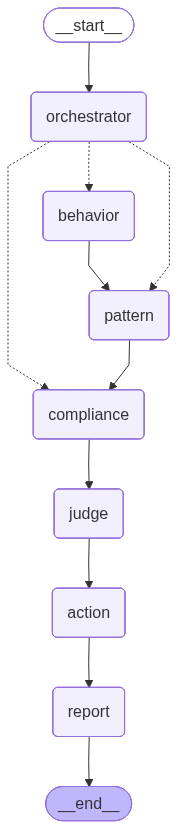

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))